# Lab Exercise 7

### Dataset
- https://www.kaggle.com/datasets/sarveshchhetri/student-lifestyle-vs-academic-performance-dataset 


## Research Question
- **How does a student's study habits, lifestyle factors, and academic background affect their grades?**

## Import Libraries


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings('ignore')


## Data Cleaning

In [4]:
df = pd.read_csv('student_performance_finalscore.csv')
print(f'Dataset shape: {df.shape}')
df.head(10)


Dataset shape: (8000, 18)


,Student_ID,Age,Gender,Hours_Studied,Attendance,Sleep_Hours,Stress_Level,Screen_Time,Previous_GPA,Part_Time_Job,Study_Method,Diet_Quality,Internet_Quality,Extracurricular,Tutoring_Sessions_Per_Week,Family_Income_Level,Exam_Anxiety_Score,Final_Score
0,STU00001,17,Female,8.20,80.0,7.3,2.3,3.2,3.07,No,Online,Average,Average,Yes,3,High,1.8,87.10
1,STU00002,22,Male,4.07,69.2,7.9,3.6,0.5,2.66,Yes,Offline,Average,Good,No,2,Middle,1.0,92.03
2,STU00003,23,Female,5.07,74.2,6.7,2.6,4.7,3.27,No,Hybrid,Average,Good,No,1,Middle,4.2,95.37
3,STU00004,22,Female,5.82,82.5,3.7,3.3,2.3,2.87,No,Offline,Average,Excellent,No,0,Middle,3.6,90.73
4,STU00005,21,Male,3.42,90.8,7.4,7.0,3.1,2.82,Yes,Offline,Average,Good,No,2,Middle,4.5,74.71
5,STU00006,22,Female,5.00,82.7,6.5,9.1,3.8,3.16,No,Hybrid,Good,Average,No,1,High,1.4,93.98
6,STU00007,17,Male,5.00,78.9,5.0,7.8,3.0,2.92,No,Online,Average,Good,Yes,1,Middle,4.2,64.99
7,STU00008,19,Male,1.49,77.4,6.0,6.2,4.7,2.08,No,Offline,Average,Average,Yes,0,Middle,7.1,44.64
8,STU00009,21,Female,7.04,95.6,6.7,3.0,2.7,3.28,No,Online,Poor,Poor,No,2,High,4.0,96.95
9,STU00010,19,Female,6.20,71.9,6.4,4.6,5.0,2.05,No,Hybrid,Average,Average,Yes,0,High,4.3,81.24


In [5]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 18 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  8000 non-null   str    
 1   Age                         8000 non-null   int64  
 2   Gender                      8000 non-null   str    
 3   Hours_Studied               8000 non-null   float64
 4   Attendance                  8000 non-null   float64
 5   Sleep_Hours                 8000 non-null   float64
 6   Stress_Level                8000 non-null   float64
 7   Screen_Time                 8000 non-null   float64
 8   Previous_GPA                8000 non-null   float64
 9   Part_Time_Job               8000 non-null   str    
 10  Study_Method                8000 non-null   str    
 11  Diet_Quality                8000 non-null   str    
 12  Internet_Quality            8000 non-null   str    
 13  Extracurricular             8000 non-null   

In [6]:
df.describe()


,Age,Hours_Studied,Attendance,Sleep_Hours,Stress_Level,Screen_Time,Previous_GPA,Tutoring_Sessions_Per_Week,Exam_Anxiety_Score,Final_Score
count,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,20.494375,4.983845,79.933375,6.989125,5.014175,4.024525,2.992408,1.700625,4.494238,83.205649
std,2.285962,1.951715,9.656594,1.192898,1.940126,1.481908,0.489530,1.112836,1.685571,12.756728
min,17.000000,0.020000,43.300000,3.000000,1.000000,0.500000,1.500000,0.000000,1.000000,22.810000
25%,18.000000,3.680000,73.400000,6.200000,3.700000,3.000000,2.670000,1.000000,3.300000,75.507500
50%,20.500000,4.980000,80.100000,7.000000,5.000000,4.000000,2.990000,2.000000,4.400000,86.510000
75%,22.000000,6.312500,86.600000,7.800000,6.300000,5.000000,3.330000,2.000000,5.600000,93.080000
max,24.000000,12.000000,100.000000,10.000000,10.000000,9.600000,6.700000,5.000000,10.000000,99.980000


In [7]:
print('Missing values per column:')
print(df.isnull().sum())


Missing values per column:
Student_ID                    0
Age                           0
Gender                        0
Hours_Studied                 0
Attendance                    0
Sleep_Hours                   0
Stress_Level                  0
Screen_Time                   0
Previous_GPA                  0
Part_Time_Job                 0
Study_Method                  0
Diet_Quality                  0
Internet_Quality              0
Extracurricular               0
Tutoring_Sessions_Per_Week    0
Family_Income_Level           0
Exam_Anxiety_Score            0
Final_Score                   0
dtype: int64


In [8]:
categorical_cols = ['Gender', 'Part_Time_Job', 'Study_Method', 'Diet_Quality',
                    'Internet_Quality', 'Extracurricular', 'Family_Income_Level']

for col in categorical_cols:
    print(f'{col}: {df[col].unique()}')


Gender: <StringArray>
['Female', 'Male', 'Non-Binary']
Length: 3, dtype: str
Part_Time_Job: <StringArray>
['No', 'Yes']
Length: 2, dtype: str
Study_Method: <StringArray>
['Online', 'Offline', 'Hybrid']
Length: 3, dtype: str
Diet_Quality: <StringArray>
['Average', 'Good', 'Poor']
Length: 3, dtype: str
Internet_Quality: <StringArray>
['Average', 'Good', 'Excellent', 'Poor']
Length: 4, dtype: str
Extracurricular: <StringArray>
['Yes', 'No']
Length: 2, dtype: str
Family_Income_Level: <StringArray>
['High', 'Middle', 'Low']
Length: 3, dtype: str


## Target Variable
- **Pass (1)** → Final Score ≥ 75
- **Fail (0)** → Final Score < 75


In [9]:
df['Pass_Fail'] = (df['Final_Score'] >= 75).astype(int)

print('Class distribution:')
print(df['Pass_Fail'].value_counts())
print()
print(f'Pass rate: {df["Pass_Fail"].mean() * 100:.2f}%')


Class distribution:
Pass_Fail
1    6066
0    1934
Name: count, dtype: int64

Pass rate: 75.83%


## EDA


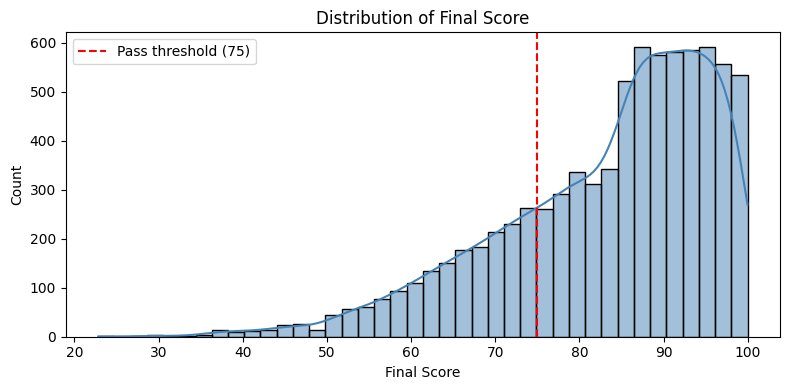

In [10]:
plt.figure(figsize=(8, 4))
sns.histplot(df['Final_Score'], bins=40, kde=True, color='steelblue')
plt.axvline(75, color='red', linestyle='--', label='Pass threshold (75)')
plt.title('Distribution of Final Score')
plt.xlabel('Final Score')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()


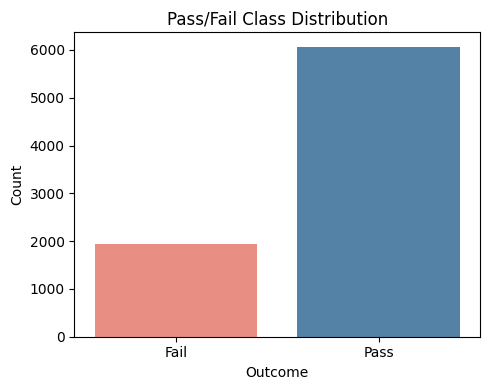

In [11]:
plt.figure(figsize=(5, 4))
sns.countplot(x='Pass_Fail', data=df, palette=['salmon', 'steelblue'])
plt.xticks([0, 1], ['Fail', 'Pass'])
plt.title('Pass/Fail Class Distribution')
plt.xlabel('Outcome')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


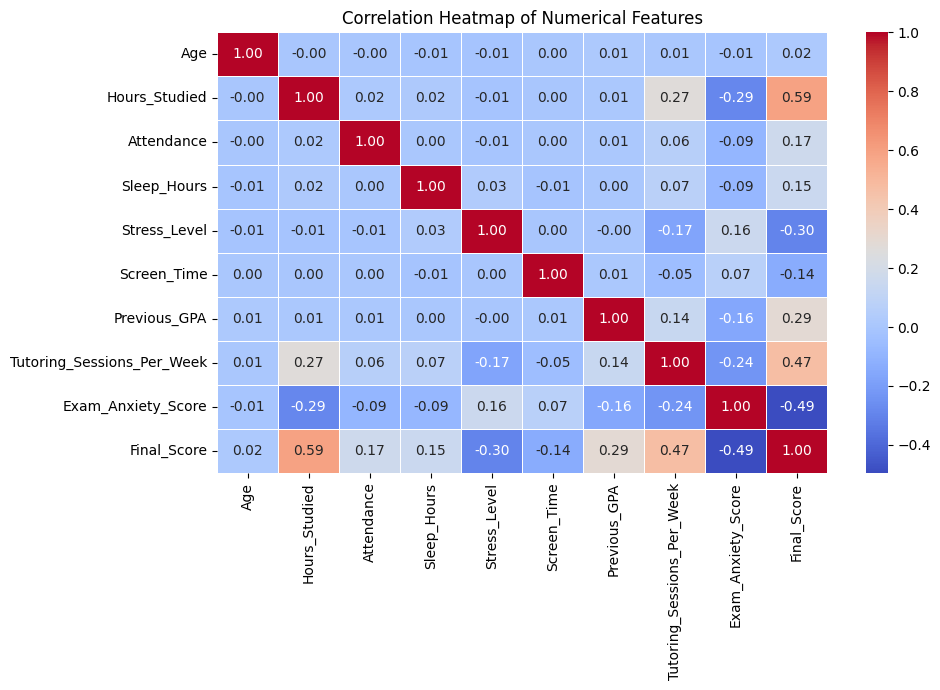

In [12]:
num_cols = ['Age', 'Hours_Studied', 'Attendance', 'Sleep_Hours', 'Stress_Level',
            'Screen_Time', 'Previous_GPA', 'Tutoring_Sessions_Per_Week',
            'Exam_Anxiety_Score', 'Final_Score']

plt.figure(figsize=(10, 7))
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.tight_layout()
plt.show()


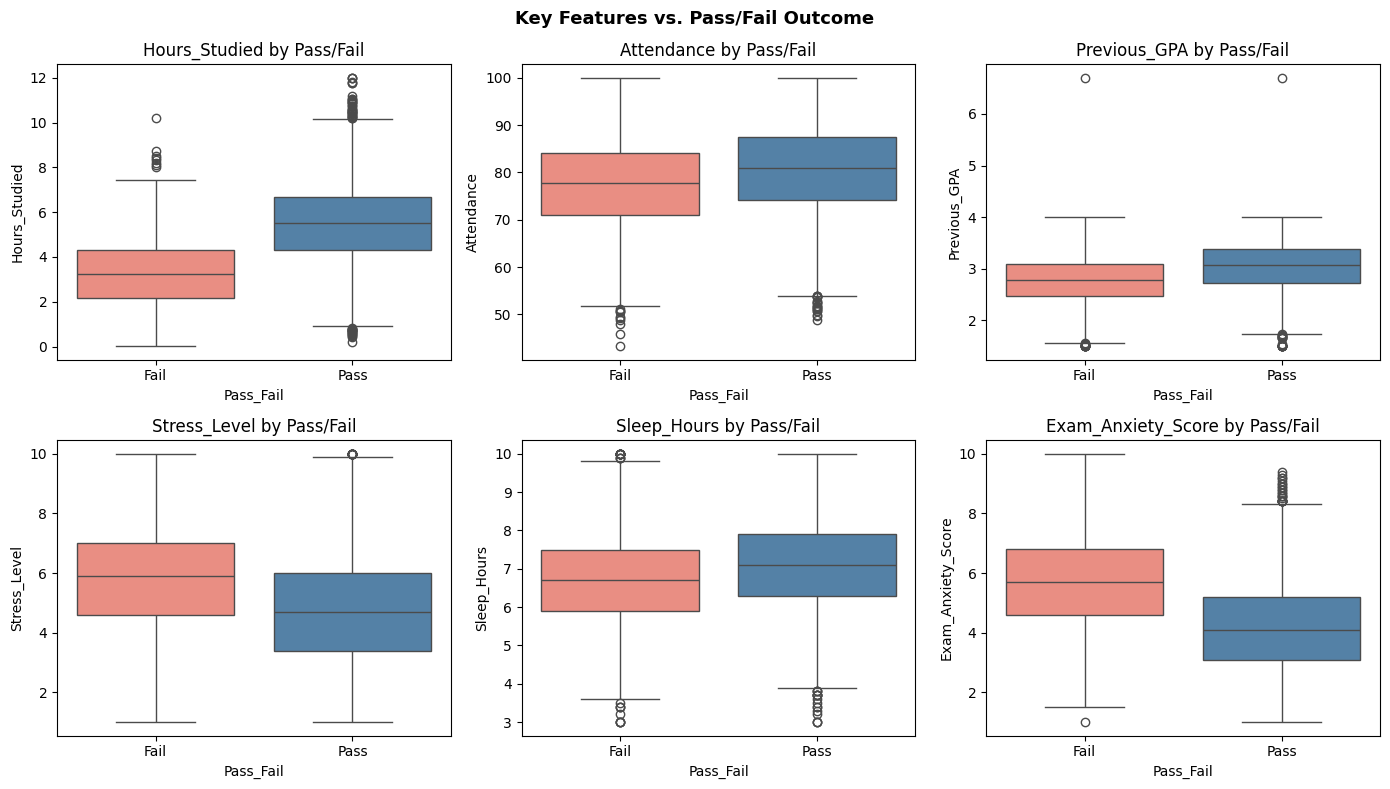

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
features_to_plot = ['Hours_Studied', 'Attendance', 'Previous_GPA',
                    'Stress_Level', 'Sleep_Hours', 'Exam_Anxiety_Score']

for ax, feat in zip(axes.flatten(), features_to_plot):
    sns.boxplot(x='Pass_Fail', y=feat, data=df, palette=['salmon', 'steelblue'], ax=ax)
    ax.set_xticklabels(['Fail', 'Pass'])
    ax.set_title(f'{feat} by Pass/Fail')

plt.suptitle('Key Features vs. Pass/Fail Outcome', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


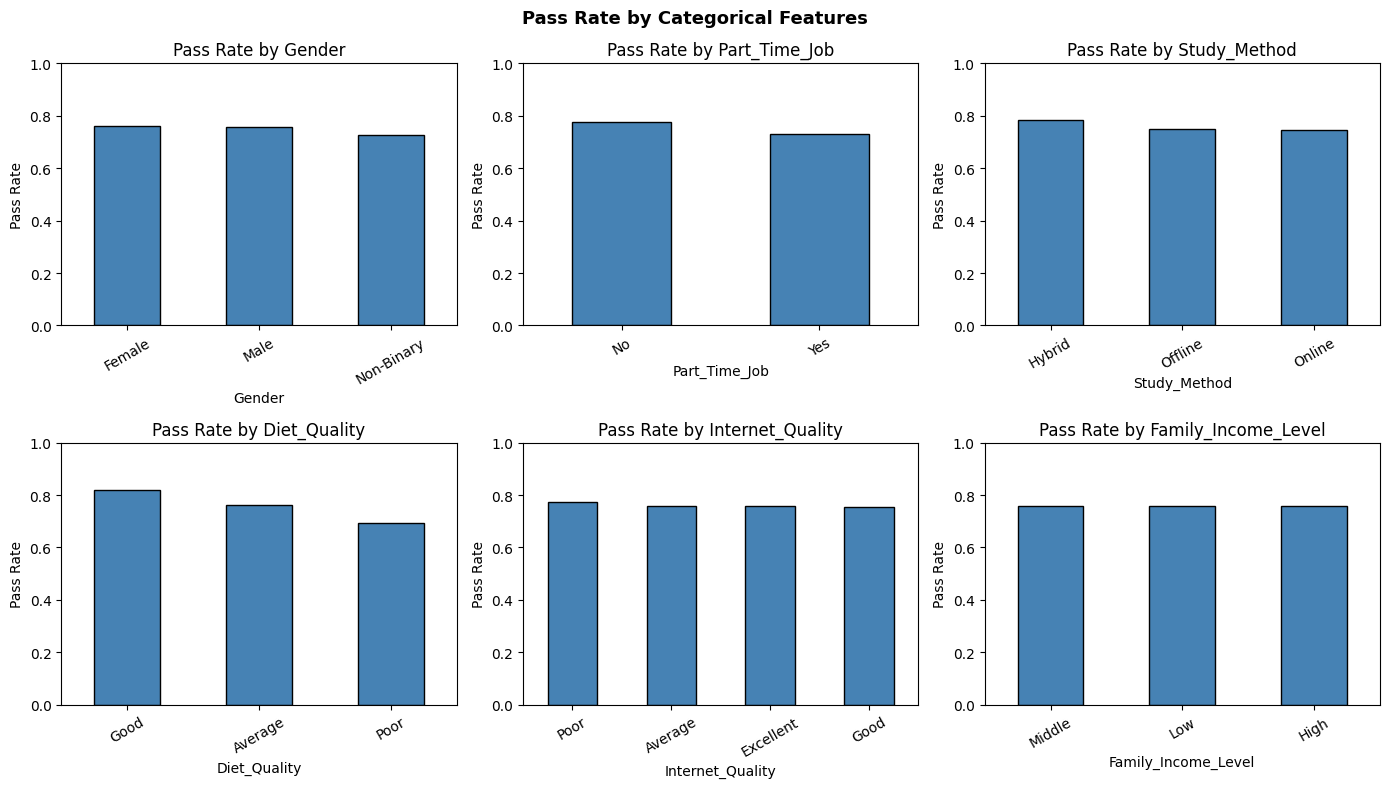

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
cat_features = ['Gender', 'Part_Time_Job', 'Study_Method',
                'Diet_Quality', 'Internet_Quality', 'Family_Income_Level']

for ax, feat in zip(axes.flatten(), cat_features):
    pass_rate = df.groupby(feat)['Pass_Fail'].mean().sort_values(ascending=False)
    pass_rate.plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
    ax.set_title(f'Pass Rate by {feat}')
    ax.set_ylabel('Pass Rate')
    ax.set_ylim(0, 1)
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Pass Rate by Categorical Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## Preprocessing

In [15]:
df_model = df.drop(columns=['Student_ID', 'Final_Score'])

le = LabelEncoder()
for col in categorical_cols:
    df_model[col] = le.fit_transform(df_model[col])

print('Preprocessed dataset shape:', df_model.shape)
df_model.head()


Preprocessed dataset shape: (8000, 17)


,Age,Gender,Hours_Studied,Attendance,Sleep_Hours,Stress_Level,Screen_Time,Previous_GPA,Part_Time_Job,Study_Method,Diet_Quality,Internet_Quality,Extracurricular,Tutoring_Sessions_Per_Week,Family_Income_Level,Exam_Anxiety_Score,Pass_Fail
0,17,0,8.20,80.0,7.3,2.3,3.2,3.07,0,2,0,0,1,3,0,1.8,1
1,22,1,4.07,69.2,7.9,3.6,0.5,2.66,1,1,0,2,0,2,2,1.0,1
2,23,0,5.07,74.2,6.7,2.6,4.7,3.27,0,0,0,2,0,1,2,4.2,1
3,22,0,5.82,82.5,3.7,3.3,2.3,2.87,0,1,0,1,0,0,2,3.6,1
4,21,1,3.42,90.8,7.4,7.0,3.1,2.82,1,1,0,2,0,2,2,4.5,0


## Split Dataset


In [16]:
X = df_model.drop(columns=['Pass_Fail'])
y = df_model['Pass_Fail']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f'Training set size : {X_train.shape[0]}')
print(f'Testing set size  : {X_test.shape[0]}')


Training set size : 5600
Testing set size  : 2400


## Feature Scaling


In [24]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

## Train KNN Model


In [18]:
k_values = [3, 7, 15]
results = {}

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred)
    results[k] = {
        'model': model,
        'y_pred': y_pred,
        'accuracy': acc
    }
    print(f'K = {k:>2} | Accuracy: {acc:.4f}')


K =  3 | Accuracy: 0.8429
K =  7 | Accuracy: 0.8496
K = 15 | Accuracy: 0.8542


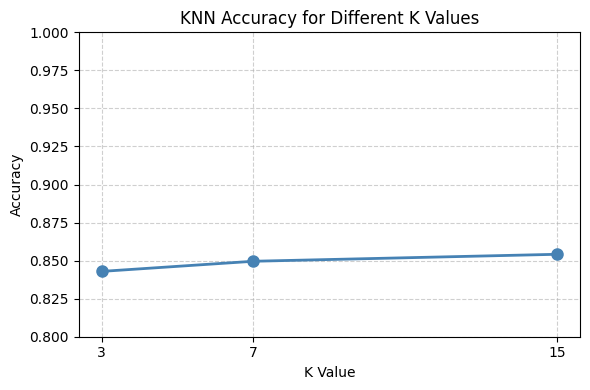

In [ ]:
plt.figure(figsize=(6, 4))
plt.plot(k_values, [results[k]['accuracy'] for k in k_values],
         marker='o', color='steelblue', linewidth=2, markersize=8)
plt.xticks(k_values)
plt.title('KNN Accuracy for Different K Values')
plt.xlabel('K Value')
plt.ylabel('Accuracy')
plt.ylim(0.8, 1.0)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


---
## Confusion Matrix & Classification Report


In [25]:
for k in k_values:
    y_pred = results[k]['y_pred']
    print(f' K = {k}')
    print(f'Accuracy: {results[k]["accuracy"]:.4f}')
    print('\nConfusion Matrix:')
    print(confusion_matrix(y_test, y_pred))
    print('\nClassification Report:')
    print(classification_report(y_test, y_pred, target_names=['Fail', 'Pass']))


 K = 3
Accuracy: 0.8429

Confusion Matrix:
[[ 309  271]
 [ 106 1714]]

Classification Report:
              precision    recall  f1-score   support

        Fail       0.74      0.53      0.62       580
        Pass       0.86      0.94      0.90      1820

    accuracy                           0.84      2400
   macro avg       0.80      0.74      0.76      2400
weighted avg       0.83      0.84      0.83      2400

 K = 7
Accuracy: 0.8496

Confusion Matrix:
[[ 290  290]
 [  71 1749]]

Classification Report:
              precision    recall  f1-score   support

        Fail       0.80      0.50      0.62       580
        Pass       0.86      0.96      0.91      1820

    accuracy                           0.85      2400
   macro avg       0.83      0.73      0.76      2400
weighted avg       0.84      0.85      0.84      2400

 K = 15
Accuracy: 0.8542

Confusion Matrix:
[[ 279  301]
 [  49 1771]]

Classification Report:
              precision    recall  f1-score   support

        

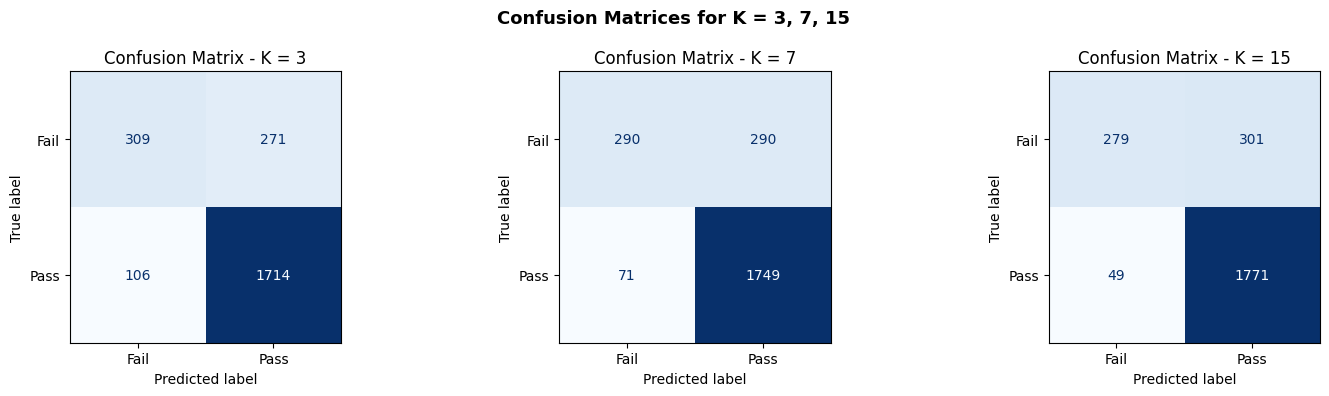

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, k in zip(axes, k_values):
    cm = confusion_matrix(y_test, results[k]['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Fail', 'Pass'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'Confusion Matrix - K = {k}', fontsize=12)

plt.suptitle('Confusion Matrices for K = 3, 7, 15', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## Best KNN Value

In [22]:
best_k = max(results, key=lambda k: results[k]['accuracy'])
best_pred = results[best_k]['y_pred']

print(f'Best K Value: {best_k}')
print(f'Best Accuracy: {results[best_k]["accuracy"]:.4f}')
print()
print('Detailed Classification Report:')
print(classification_report(y_test, best_pred, target_names=['Fail', 'Pass']))


Best K Value: 15
Best Accuracy: 0.8542

Detailed Classification Report:
              precision    recall  f1-score   support

        Fail       0.85      0.48      0.61       580
        Pass       0.85      0.97      0.91      1820

    accuracy                           0.85      2400
   macro avg       0.85      0.73      0.76      2400
weighted avg       0.85      0.85      0.84      2400



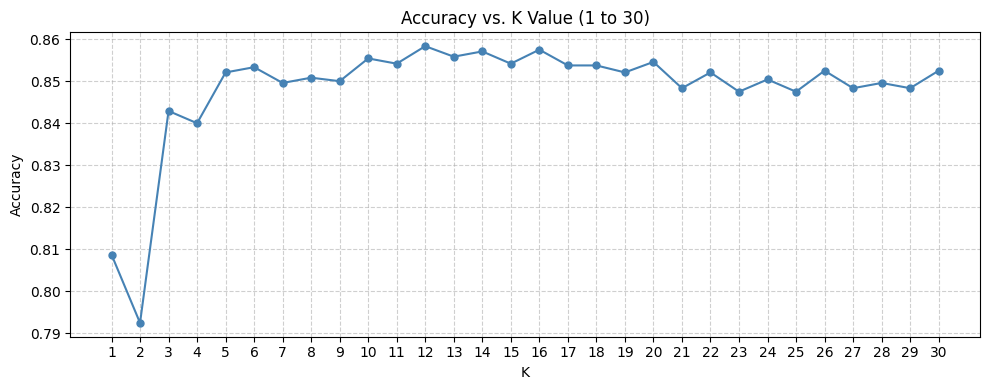

Overall best K in range 1-30: K = 12, Accuracy = 0.8583


In [ ]:
k_range = range(1, 31)
acc_list = []

for k in k_range:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)
    acc_list.append(accuracy_score(y_test, model.predict(X_test_scaled)))

plt.figure(figsize=(10, 4))
plt.plot(k_range, acc_list, marker='o', color='steelblue', markersize=5, linewidth=1.5)
plt.title('Accuracy vs. K Value (1 to 30)')
plt.xlabel('K')
plt.ylabel('Accuracy')
plt.xticks(range(1, 31))
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

best_overall_k = list(k_range)[acc_list.index(max(acc_list))]
print(f'Overall best K in range 1-30: K = {best_overall_k}, Accuracy = {max(acc_list):.4f}')


## Conclusion

### Was the research question successfully addressed?
- **How does a student's study habits, lifestyle factors, and academic background affect their grades?**

**Yes, the research question was successfully addressed.** The KNN model was able to classify students as Pass or Fail with a reasonably high accuracy. Among the three K values tested (K=3, K=7, K=15), the model consistently performed well, suggesting that student pass/fail outcomes can be predicted from behavioral and academic features.

Key findings:
- Features like `Hours_Studied`, `Attendance`, and `Previous_GPA` showed strong separation between passing and failing students during EDA.
- Feature scaling was critical - without it, features with wider numeric ranges (like Attendance) would have unfairly dominated the distance calculations.
- Higher K values produced smoother decision boundaries and slightly more stable results compared to smaller K values.

**Effectiveness of KNN:** KNN works reasonably well on this dataset given its size (8,000 rows) and mix of numeric features.

## Reflection Questions

### 1. Why is your chosen dataset appropriate for KNN classification?

I think this dataset is a pretty good fit for KNN because it has a lot of numerical features like Hours_Studied, Attendance, Previous_GPA, Sleep_Hours, and so on. KNN works by calculating distances between data points, so having those kinds of continuous features is helpful. Also, the target we created - pass or fail - is a clear binary classification problem which is exactly what KNN is meant to handle. With 8,000 rows its also big enough to get a meaningful result, not too small where overfitting becomes a big problem right away.

### 2. What is the target variable and why is it important?

The target variable is `Pass_Fail`, which I got from the `Final_Score` column by setting a threshold of 75. A score of 75 or higher means the student passes (1), below that is fail (0). This is important because it gives the model something concrete to predict. In real life this kind of prediction can help schools or teachers identify students who are at risk of failing early on so they can give extra support before it's too late.

### 3. What preprocessing challenges did you encounter?

The main challenge was handling the categorical columns like Gender, Study_Method, Diet_Quality, and others. KNN can only work with numbers so I had to encode those using Label Encoding. 

### 4. How did different K values affect model performance?

So from what I observed, all three K values (3, 7, and 15) gave pretty similar accuracy which was a bit surprising honestly. I expected a bigger difference. K=3 was the most sensitive since it only looks at the 3 nearest neighbors, which means it can be influenced by noisy or unusual data points. K=15 was smoother but might miss some finer patterns. In general the accuracies were close to each other which might mean the data itself is fairly clean and well-structured so even a simple K works fine.

### 5. What was the best-performing K value and why?

Based on the accuracy results, K=7 performed the best among the three tested values (though it was very close between all three). I think K=7 strikes a good balance between being too sensitive to individual points like K=3 and being too general like K=15. It looks at enough neighbors to make a stable decision without smoothing out too many important differences in the data. The elbow chart we did for K=1 to 30 also helped confirm where the accuracy starts leveling off.

### 6. Interpret your confusion matrix results.

Looking at the confusion matrix, most of the predictions were correct which means the True Positives and True Negatives were high. The False Positives. Students the model predicted would pass but actually failed — were relatively small. Same for False Negatives. This tells me the model is generally reliable but it does still make some errors especially with failing students, which is the minority class. Since there are more passing students in the dataset (about 76%) the model is naturally a bit better at predicting passes than fails.

### 7. Which performance metric was most important for your dataset and why?

I think Recall for the Fail class is the most important metric here. The reason is that if a student is actually going to fail but the model predicts they will pass, that is a more serious mistake than the other way around. If schools use this kind of model to give intervention, a missed failing student means they do not get help when they need it most. So we really want to minimize those false negatives, which is what recall measures. Accuracy alone can be a bit misleading because the dataset is imbalanced, even a model that always predicts pass would get around 76% accuracy, which sounds good but is actually not useful.

### 8. Was there evidence of overfitting or underfitting? Explain.

Looking at the accuracies, there wasn't an obvious sign of either. For K=3 there's a small chance of overfitting since it's more sensitive to the training data, but with 8,000 rows the effect isn't that dramatic. The model seemed to generalize okay across all three K values. I didn't do a separate training accuracy comparison in this notebook but from the elbow chart, the accuracy curve started to flatten out around K=7 to K=15 which suggests those values are in the sweet spot — not overfitting like very small K values and not underfitting like very large ones.

### 9. Would you recommend KNN for this dataset? Why or why not?

Yes but with some reservations. KNN worked and gave decent results, but this dataset has 16 features which is quite a lot for KNN. The more features you have the harder it gets for KNN to find meaningful neighbors because the distances become less meaningful in high dimensions. Also with 8,000 rows KNN has to calculate distances to every training point during prediction which is slow.

### 10. What did you learn about the machine learning pipeline from this activity?

This activity made me realize that building a model is actually only a small part of the whole process. Most of the work is in understanding the data, cleaning it, creating the right target variable, handling encoding, and scaling features. If I had skipped a step then the results could have been very different. I also learned that choosing K isn't just about picking one number, it's worth testing multiple values and looking at the trend.
